In [1]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb
from spatialmath import SE3

# set matplotlib to interactive mode for inline plotting
plt.ion()
# %matplotlib widget


In [2]:
robot = rtb.models.DH.UR5()
robot.tool = SE3.Tz(0.1)  # Tool frame offset
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──────┬─────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = 0°, 0°, 0° │
└──────┴─────────────────────────────────────┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



In [3]:
# 1. Mass of the links
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.275
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1879

# 2. Center of mass of each link
robot.links[0].r = [0.0, 0.0, 0.0]
robot.links[1].r = [-0.2125, 0.0, 0.136]
robot.links[2].r = [-0.196125, 0.0, 0.0165]
robot.links[3].r = [0.0, 0.0, 0.0]
robot.links[4].r = [0.0, 0.0, 0.0]
robot.links[5].r = [0.0, 0.0, -0.01525]

# 3. Inertia tensor of each link [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]
robot.links[0].I = [0.014972352344389999, 0.014972352344389999, 0.01040625, 0.0, 0.0, 0.0]
robot.links[1].I = [0.1338857818623325, 0.1338857818623325, 0.0151074, 0.0, 0.0, 0.0]
robot.links[2].I = [0.03121679102890359, 0.03121679102890359, 0.004095, 0.0, 0.0, 0.0]
robot.links[3].I = [0.0020138887777775, 0.0020138887777775, 0.0021942, 0.0, 0.0, 0.0]
robot.links[4].I = [0.0018310388509175, 0.0018310388509175, 0.0021942, 0.0, 0.0, 0.0]
robot.links[5].I = [8.062472608343e-05, 8.062472608343e-05, 0.0001321171875, 0.0, 0.0, 0.0]

# 4. Moment of inertia of the drive
for i in range(6): robot.links[i].Jm = 0.0

# 5. Coefficient of viscous friction
for i in range(6): robot.links[i].B = 0.0

# 6. Coefficient of Coulomb friction
for i in range(6): robot.links[i].Tc = [0.0, 0.0]

# 7. Gear ratio
for i in range(6): robot.links[i].G = 1

# 8. Restrictions on the generalized coordinates
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-pi, pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

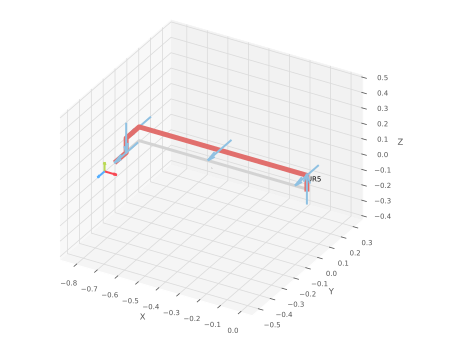

In [4]:
q_start = np.array([0, 0, 0, 0, 0, 0])
# q_start = robot.qr
robot.plot(q_start)
plt.show()

In [5]:
T_start = robot.fkine(q_start)
print(T_start)

   1         0         0        -0.8173    
   0         0        -1        -0.2914    
   0         1         0        -0.005191  
   0         0         0         1         



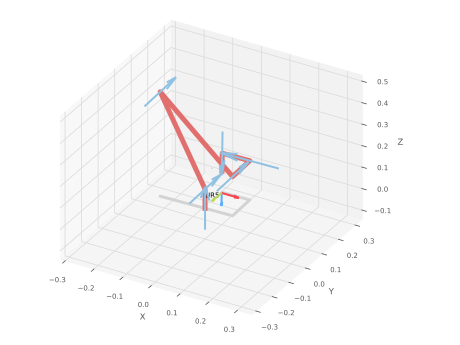

   1        -5.22e-06  0.0005424 -0.002976  
   5.221e-06 -0.9998   -0.01925   0.1056    
   0.0005424  0.01925  -0.9998    2.707e-09  
   0         0         0         1         

[ 3.16977053 -1.9419366   2.82568259  0.68705034  1.59005095  1.5989742 ]


In [22]:
point = [-0.2, 0.0, 0.5]
T_end = sb.transl(point) * sb.rpy2tr([pi, 0, 0], order='zyx')
q_end = robot.ikine_LM(T_end).q  # Other methods available besides ikine_GN
robot.plot(q_end)
plt.show()

T_end_verified = robot.fkine(q_end)
print(T_end_verified)
print(q_end)

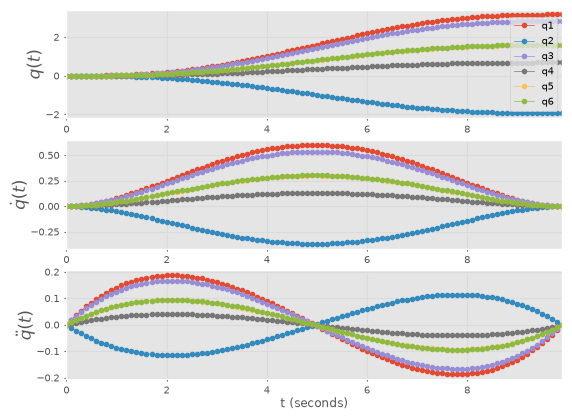

In [23]:
N = 100
t_start = 0
t_stop = 10
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)
tr.plot()

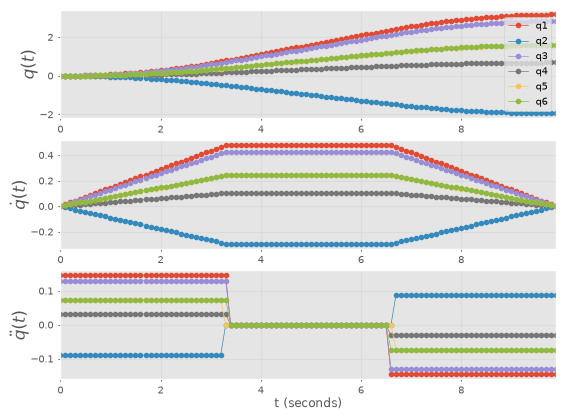

In [24]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)
tr_trap.plot()

In [25]:
import mujoco
import mujoco.viewer
import numpy as np
import time
import mediapy as media

# Load the UR5e model
model = mujoco.MjModel.from_xml_path(
    "../mujoco_menagerie/universal_robots_ur5e/scene.xml"
)
data = mujoco.MjData(model)

print("=== UR5e Model Info ===")
print(f"Number of joints (DoF): {model.nv}")
print(f"Number of actuators:    {model.nu}")
print(f"Joint names:")
for i in range(model.njnt):
    print(f"  Joint {i}: {mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i)}")

=== UR5e Model Info ===
Number of joints (DoF): 6
Number of actuators:    6
Joint names:
  Joint 0: shoulder_pan_joint
  Joint 1: shoulder_lift_joint
  Joint 2: elbow_joint
  Joint 3: wrist_1_joint
  Joint 4: wrist_2_joint
  Joint 5: wrist_3_joint


In [26]:
cam = mujoco.MjvCamera()
cam.lookat[:] = [0.0, 0.0, 0.5]
cam.distance = 2.5
cam.azimuth = 90
cam.elevation = -20

""

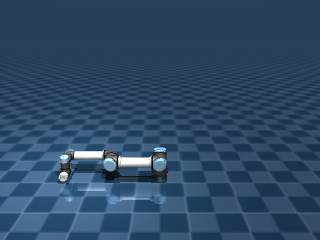

""

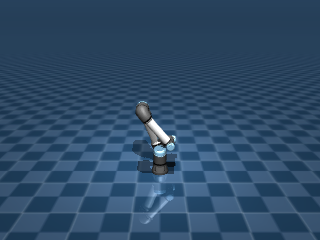

In [27]:


# Launch interactive viewer
# print("\nLaunching viewer... (close the window to exit)")
# with mujoco.viewer.launch_passive(model, data) as viewer:
#     start_time = time.time()
#     while viewer.is_running():
#         t = time.time() - start_time

#         # Simple sinusoidal motion on joint 0 (shoulder pan)
#         data.ctrl[0] = 0.5 * np.sin(0.5 * t)   # shoulder_pan_joint
#         data.ctrl[1] = -1.0 + 0.3 * np.sin(0.3 * t)  # shoulder_lift_joint

#         mujoco.mj_step(model, data)
#         viewer.sync()
#         time.sleep(0.002)  # ~500 Hz simulation
def preview_pose_sim(pose: np.ndarray):
  with mujoco.Renderer(model) as renderer:
    data.qpos[:6] = pose  # Set the joint positions
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera=cam)
    media.show_image(renderer.render())

preview_pose_sim(q_start)
preview_pose_sim(q_end)

In [28]:
framerate = 60  # (Hz)
duration = len(tr.q) / framerate  # (seconds)


trajectory = tr_trap

q_history = []
qd_history = []
qdd_history = []

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:

    # assign the joint positions from the trajectory to the simulation data
    q = trajectory.q[int(data.time * framerate)]
    # qd = trajectory.qd[int(data.time * framerate)]
    # qdd = trajectory.qdd[int(data.time * framerate)]

    # data.qpos[:6] = q
    # data.qvel[:6] = qd
    # data.qacc[:6] = qdd

    data.ctrl[:6] = q  # Set the control inputs to the joint positions

    q_history.append(data.qpos[:6].copy())  # Store the joint positions for later analysis
    qd_history.append(data.qvel[:6].copy())  # Store the joint velocities for later analysis
    qdd_history.append(data.qacc[:6].copy())  # Store the joint accelerations for later analysis

    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, camera=cam)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [29]:
# Plot the joint positions over time
q_history = np.array(q_history)
q_history.shape

(834, 6)

In [30]:
qd_history = np.array(qd_history)
qdd_history = np.array(qdd_history)

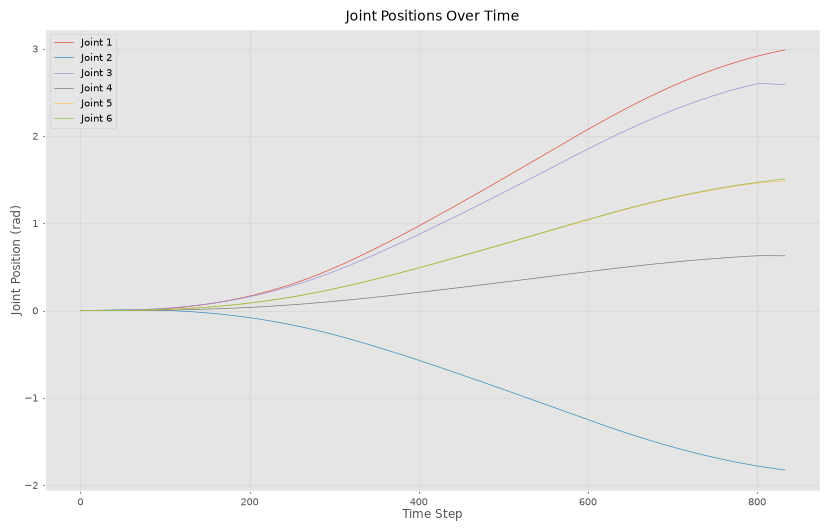

In [31]:
# plot 6 joint positions over time in 1 plot with different colors for each joint
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.plot(q_history[:, i], label=f'Joint {i+1}', color=f'C{i}') 
# plt.plot(q_history[:, 0], label=f'Joint {0+1}', color=f'C{0}') 
plt.title('Joint Positions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Joint Position (rad)')
plt.legend()
plt.show()

In [32]:
end_pose_sim = q_history[-1,:]
T_end_sim = robot.fkine(end_pose_sim)
print(T_end_sim)
    

   0.9789   -0.07953   0.1881    0.1332    
  -0.09143  -0.9943    0.05543   0.105     
   0.1826   -0.07146  -0.9806    0.03371   
   0         0         0         1         



In [33]:
print(T_end_verified)

   1        -5.22e-06  0.0005424 -0.002976  
   5.221e-06 -0.9998   -0.01925   0.1056    
   0.0005424  0.01925  -0.9998    2.707e-09  
   0         0         0         1         



# Calculate the joint angles for the robot to follow the trajectory

In [34]:
%store -r robot_traj

In [35]:
robot_traj

array([[452.80978394, 263.91033936, 110.        ],
       [452.80978394, 263.91033936, 100.        ],
       [452.27173996, 264.44839478, 100.        ],
       ...,
       [441.24184799,  62.1440239 , 100.        ],
       [430.75      ,  55.68750381, 100.        ],
       [430.75      ,  55.68750381, 110.        ]], shape=(1025, 3))